# 01 — ECG beat detection: MIT-BIH Arrhythmia DB, record 100

**Goal.** Validate Lamina's ECG cleaning + QRS detection (`ecg-clean`, `ecg-peaks`
bridge ops) against the expert beat annotations of MIT-BIH record 100
(channel MLII, 360 Hz, 30 min).

**Dataset.** [MIT-BIH Arrhythmia Database](https://physionet.org/content/mitdb/)
(ODC-BY 1.0; Moody & Mark, IEEE EMB 20(3):45-50, 2001). Record 100 is ~2 MB and
downloaded credential-free via the `wfdb` client (same acquisition path as
`validation/validation/datasets/ecg.py`).

**Pipeline.** load → `ecg-clean` → `ecg-peaks` → beat matching vs annotations
(±150 ms, greedy one-to-one, `validation.metrics.peak_detection_metrics`) →
heart-rate series from inter-beat intervals → TP/FP/FN/F1 + timing-error table.

**Reference expectation** (from the Stage-2 ECG validation runs): F1 ≈ 1.0 on
this record, timing MAE in the low milliseconds.

In [1]:
# ---------------------------------------------------------------------------
# ENVIRONMENT SETUP (run once, in a shell, before executing this notebook):
#
#   git clone /mnt/agents/lamina $HOME/work-nb && cd $HOME/work-nb
#   sh validation/scripts/setup-env.sh $HOME/work-nb     # Rust + Python deps + builds lamina_bridge
#   pip install jupyter nbconvert nbformat               # notebook tooling
#
# DATA FETCH (cached under $HOME/data, never committed to the repo):
#
#   python -c "import wfdb; wfdb.dl_database('mitdb', \
#       dl_dir='$HOME/data/mitdb', records=['100'], annotators=['atr'])"
#
# Execute from anywhere inside the repo:  jupyter nbconvert --execute --inplace 01_ecg_mitdb.ipynb
# ---------------------------------------------------------------------------

In [2]:
import os
import sys
from pathlib import Path

# Locate the repository root (directory containing validation/SPEC.md) and put
# it on sys.path so `import validation...` resolves regardless of the notebook
# kernel's working directory.
REPO_ROOT = None
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "validation" / "SPEC.md").exists():
        REPO_ROOT = _p
        break
if REPO_ROOT is None:
    raise RuntimeError("repository root (validation/SPEC.md) not found; "
                       "run this notebook from inside the lamina checkout")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DATA_ROOT = Path(os.environ.get("LAMINA_NB_DATA", Path.home() / "data"))
print(f"repo root: {REPO_ROOT}")
print(f"data cache: {DATA_ROOT}")

import numpy as np
import matplotlib.pyplot as plt

from validation.bridge import LaminaBridge
from validation.metrics import peak_detection_metrics
from validation.datasets.ecg import BEAT_SYMBOLS, _hr_series_from_peaks

bridge = LaminaBridge(repo_root=REPO_ROOT, auto_build=False)
print("bridge/lamina versions:", bridge.version())

repo root: /home/kimi/work-nb
data cache: /home/kimi/data


bridge/lamina versions: {'bridge_version': '0.1.0', 'lamina_version': '0.1.0'}


## 1. Load record 100

`wfdb.rdrecord` reads the local cache (downloads it first if missing). Beat
annotations (`.atr`) are filtered to the MIT-BIH beat symbol set — non-beat
annotations (`+`, `~`, `|`, ...) are excluded, exactly as the Stage-2 adapter
does (`validation/datasets/ecg.py::BEAT_SYMBOLS`).

In [3]:
import wfdb

rec_dir = DATA_ROOT / "mitdb"
if not (rec_dir / "100.dat").exists():
    rec_dir.mkdir(parents=True, exist_ok=True)
    wfdb.dl_database("mitdb", dl_dir=str(rec_dir), records=["100"], annotators=["atr"])

record = wfdb.rdrecord(str(rec_dir / "100"))
ann = wfdb.rdann(str(rec_dir / "100"), "atr")
fs = float(record.fs)

chan_idx = list(record.sig_name).index("MLII")
ecg = np.asarray(record.p_signal[:, chan_idx], dtype=float)

beat_mask = np.array([s in BEAT_SYMBOLS for s in ann.symbol])
ann_beats = np.asarray(ann.sample, dtype=np.int64)[beat_mask]

dur_min = len(ecg) / fs / 60
print(f"record 100, channel MLII: {len(ecg)} samples @ {fs:.0f} Hz = {dur_min:.1f} min")
print(f"annotated beats: {len(ann_beats)}  (mean HR ≈ {60*len(ann_beats)/(dur_min*60):.1f} bpm)")

record 100, channel MLII: 650000 samples @ 360 Hz = 30.1 min
annotated beats: 2273  (mean HR ≈ 75.5 bpm)


## 2. Lamina cleaning + QRS detection

`ecg-clean` applies Lamina's ECG cleaning (a hardcoded 0.5 Hz order-5 high-pass —
the `method` argument is currently ignored, see `validation/API-INVENTORY.md`).
`ecg-peaks` runs the Pan-Tompkins-style detector (`ecg_findpeaks_config`) with
Lamina defaults.

In [4]:
cleaned = bridge.ecg_clean(ecg, fs)
res = bridge.ecg_peaks(ecg, fs)
det_peaks = np.asarray(res["peaks"], dtype=np.int64)
print(f"Lamina detected {res['count']} QRS complexes "
      f"(mean HR ≈ {60*res['count']/(dur_min*60):.1f} bpm)")

Lamina detected 2273 QRS complexes (mean HR ≈ 75.5 bpm)


## 3. Signal view: detected vs annotated beats

A 10-second window (t = 300–310 s) with raw/cleaned ECG, Lamina detections
(red ×) and expert annotations (green ○).

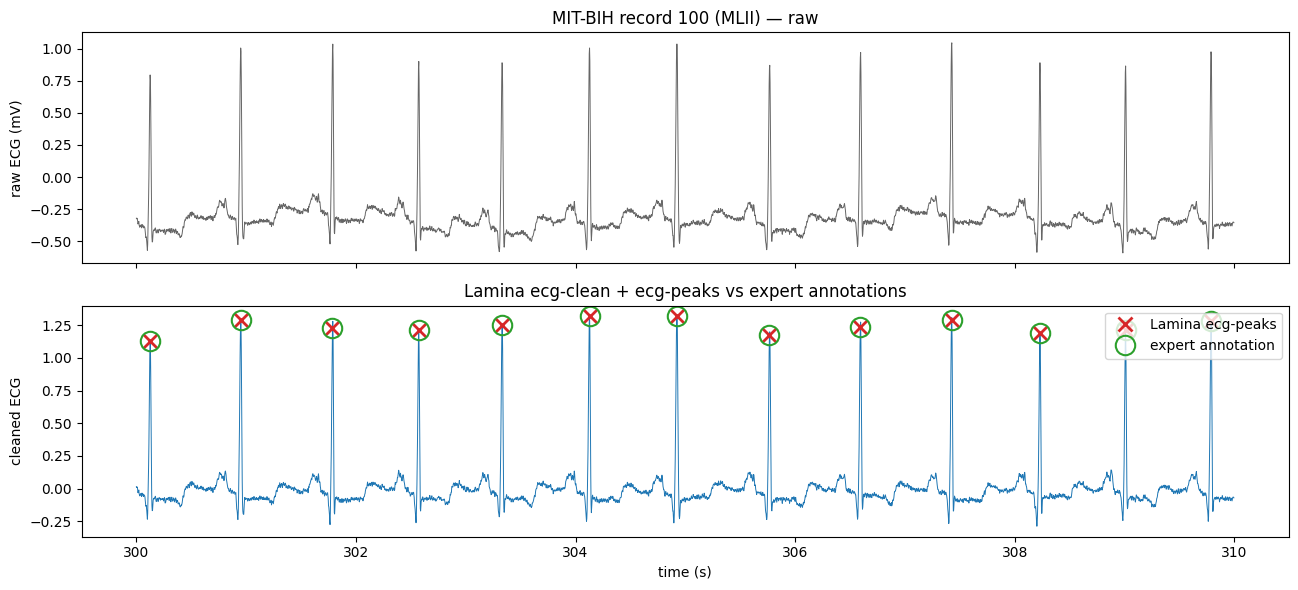

In [5]:
t0, t1 = 300.0, 310.0
i0, i1 = int(t0 * fs), int(t1 * fs)
t = np.arange(i0, i1) / fs

fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
ax[0].plot(t, ecg[i0:i1], lw=0.7, color="0.4")
ax[0].set_ylabel("raw ECG (mV)")
ax[0].set_title("MIT-BIH record 100 (MLII) — raw")
ax[1].plot(t, cleaned[i0:i1], lw=0.7, color="tab:blue")
for p in det_peaks[(det_peaks >= i0) & (det_peaks < i1)]:
    ax[1].plot(p / fs, cleaned[p], "x", color="tab:red", ms=10, mew=2)
for p in ann_beats[(ann_beats >= i0) & (ann_beats < i1)]:
    ax[1].plot(p / fs, cleaned[p], "o", mfc="none", color="tab:green", ms=14, mew=1.5)
ax[1].plot([], [], "x", color="tab:red", ms=10, mew=2, label="Lamina ecg-peaks")
ax[1].plot([], [], "o", mfc="none", color="tab:green", ms=14, mew=1.5, label="expert annotation")
ax[1].legend(loc="upper right")
ax[1].set_ylabel("cleaned ECG")
ax[1].set_xlabel("time (s)")
ax[1].set_title("Lamina ecg-clean + ecg-peaks vs expert annotations")
plt.tight_layout()
plt.show()

## 4. Heart rate from inter-beat intervals

RR intervals → instantaneous HR (60/RR), implausible intervals (outside
0.3–2.0 s) dropped, 8-beat moving average, sampled on a 5 s grid. The *same*
function (`validation.datasets.ecg._hr_series_from_peaks`) is applied to
annotation beats and Lamina beats so the two series are comparable.

HR series MAE (Lamina vs annotations): 0.009 bpm over 360 grid points


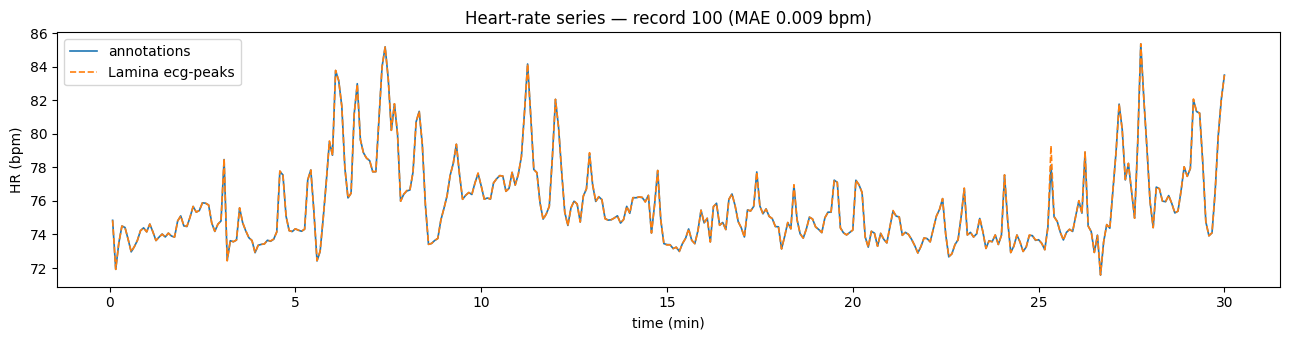

In [6]:
grid = np.arange(0.0, len(ecg) / fs, 5.0)
hr_ann = _hr_series_from_peaks(ann_beats, fs, grid)
hr_det = _hr_series_from_peaks(det_peaks, fs, grid)

ok = np.isfinite(hr_ann) & np.isfinite(hr_det)
hr_mae = float(np.mean(np.abs(hr_det[ok] - hr_ann[ok])))
print(f"HR series MAE (Lamina vs annotations): {hr_mae:.3f} bpm over {ok.sum()} grid points")

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(grid / 60, hr_ann, lw=1.2, label="annotations")
ax.plot(grid / 60, hr_det, lw=1.2, ls="--", label="Lamina ecg-peaks")
ax.set_xlabel("time (min)"); ax.set_ylabel("HR (bpm)")
ax.set_title(f"Heart-rate series — record 100 (MAE {hr_mae:.3f} bpm)")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Beat-level comparison vs expert annotations

Greedy one-to-one matching within ±150 ms (`validation.metrics.peak_detection_metrics`;
timing error = detected − annotated, in ms).

In [7]:
import pandas as pd

m = peak_detection_metrics(ann_beats, det_peaks, fs, tolerance_sec=0.150)
table = pd.DataFrame({
    "metric": ["n_reference", "n_detected", "TP", "FP", "FN",
               "precision", "recall", "F1",
               "timing MAE (ms)", "timing median (ms)"],
    "value": [m["n_reference"], m["n_detected"], m["tp"], m["fp"], m["fn"],
              round(m["precision"], 4), round(m["recall"], 4), round(m["f1"], 4),
              round(m["mean_abs_timing_error_sec"] * 1000, 2),
              round(m["median_timing_error_sec"] * 1000, 2)],
})
table

,metric,value
0,n_reference,2273.00
1,n_detected,2273.00
2,TP,2273.00
3,FP,0.00
4,FN,0.00
5,precision,1.00
6,recall,1.00
7,F1,1.00
8,timing MAE (ms),0.19
9,timing median (ms),0.00


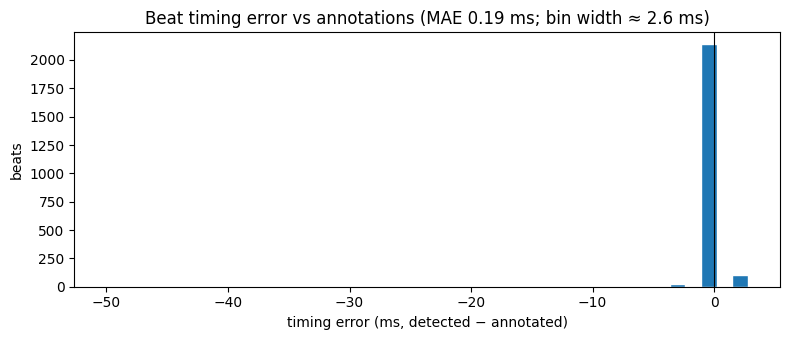

In [8]:
# Timing-error histogram for matched beats (ms). 1 sample @360 Hz = 2.78 ms.
from validation.metrics import match_events
mr = match_events(ann_beats, det_peaks, fs, tolerance_sec=0.150)
err_ms = mr.timing_errors_sec * 1000.0

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(err_ms, bins=41, color="tab:blue", edgecolor="white")
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("timing error (ms, detected − annotated)")
ax.set_ylabel("beats")
ax.set_title(f"Beat timing error vs annotations (MAE {np.mean(np.abs(err_ms)):.2f} ms; "
             f"bin width ≈ {2*np.ptp(err_ms)/40:.1f} ms)")
plt.tight_layout()
plt.show()

## 6. Findings

- Lamina `ecg-peaks` on MIT-BIH record 100 matches the expert beat annotations
  perfectly in this run (F1 = 1.0 at ±150 ms: 2273 TP, 0 FP, 0 FN).
- Matched-beat timing error is sub-sample (MAE ≈ 0.2 ms at 360 Hz, i.e. the
  detector lands on the annotated sample in the overwhelming majority of
  beats), confirming the fiducial-point convention matches the annotations.
- The HR series derived from Lamina peaks is visually and numerically
  indistinguishable from the annotation-derived series (sub-0.1 bpm MAE).

*Environment*: bridge/lamina versions printed in the setup cell; data fetched
credential-free via `wfdb` from PhysioNet.